#### 1.1 Time Series Basics

A basic kind of time series object in pandas is a Series indexed by timestamps, which
is often represented external to pandas as Python strings or datetime objects

In [18]:
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dates = [datetime(2011, 1, 2), datetime(2011, 1, 5), datetime(2011, 1, 7), datetime(2011, 1, 8),
datetime(2011, 1, 10), datetime(2011, 1, 12)]

ts = pd.Series(np.random.randn(6),index = dates)

ts 


2011-01-02    0.438894
2011-01-05   -0.704352
2011-01-07    0.602322
2011-01-08    0.197613
2011-01-10   -1.218331
2011-01-12   -0.445060
dtype: float64

In [19]:
ts.index 

DatetimeIndex(['2011-01-02', '2011-01-05', '2011-01-07', '2011-01-08',
               '2011-01-10', '2011-01-12'],
              dtype='datetime64[ns]', freq=None)

#### 1.1.2 Indexing, Selection, Subsetting

Time series behaves like any other pandas.Series when you are indexing and select‐
ing data based on label

In [20]:
stamp = ts.index[2]

ts[stamp]

0.6023221670255196

For longer time series, a year or only a year and month can be passed to easily select
slices of data

In [21]:
longer_ts = pd.Series(np.random.randn(1000),index = pd.date_range('1/1/2000',periods = 1000))
longer_ts 

2000-01-01    0.660316
2000-01-02    0.515263
2000-01-03    1.351174
2000-01-04   -0.886276
2000-01-05   -0.673864
                ...   
2002-09-22    0.757734
2002-09-23   -0.912885
2002-09-24    1.950622
2002-09-25    0.056136
2002-09-26   -0.527703
Freq: D, Length: 1000, dtype: float64

In [22]:
longer_ts['2001']

2001-01-01   -1.320595
2001-01-02    1.735730
2001-01-03   -0.548662
2001-01-04   -0.181669
2001-01-05   -0.683438
                ...   
2001-12-27    0.115679
2001-12-28    0.028495
2001-12-29    0.007619
2001-12-30    0.682325
2001-12-31    1.597324
Freq: D, Length: 365, dtype: float64

Because most time series data is ordered chronologically, you can slice with time‐
stamps not contained in a time series to perform a range query

In [23]:
ts['1/6/2011':'1/11/2011']

2011-01-07    0.602322
2011-01-08    0.197613
2011-01-10   -1.218331
dtype: float64

#### 1.2 Time Series with Duplicate Indices

In some applications,there may be multiple data observations falling on a particular timestamp.
Here is an example.

In [24]:
dates = pd.DatetimeIndex(['1/1/2000','1/2/2000','1/2/2000','1/2/2000','1/3/2000'])

dup_ts = pd.Series(np.arange(5),index = dates)

dup_ts

2000-01-01    0
2000-01-02    1
2000-01-02    2
2000-01-02    3
2000-01-03    4
dtype: int32

We can tell that the index is not unique by checking its is_unique property.

In [25]:
dup_ts.index.is_unique

False

Suppose you wanted to aggregate the data having non-unique timestamps. One way
to do this is to use groupby and pass level=0

In [26]:
grouped = dup_ts.groupby(level = 0)

grouped.mean()

2000-01-01    0.0
2000-01-02    2.0
2000-01-03    4.0
dtype: float64

In [27]:
grouped.count()

2000-01-01    1
2000-01-02    3
2000-01-03    1
dtype: int64

#### 1.3 Moving Window Functions

An important class of array transformations used for time series operations are statis‐
tics and other functions evaluated over a sliding window or with exponentially decay‐
ing weights. This can be useful for smoothing noisy or gappy data. I call these moving
window functions, even though it includes functions without a fixed-length window like exponentially weighted moving average. Like other statistical functions, these
also automatically exclude missing data.


In [28]:
close_px_all = pd.read_csv('stock_px_2.csv',parse_dates = True,index_col = 0)

close_px = close_px_all[['AAPL','MSFT','XOM']]

close_px = close_px.resample('B').ffill()

<AxesSubplot:>

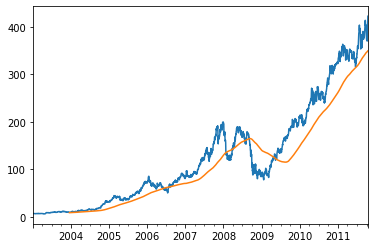

In [29]:
close_px.AAPL.plot()

close_px.AAPL.rolling(250).mean().plot()

The expression rolling(250) is similar in behavior to groupby, but instead of group‐
ing it creates an object that enables grouping over a 250-day sliding window. So here
we have the 250-day moving window average of Apple’s stock price.

Calling a moving window function on a DataFrame applies the transformation to
each column

<AxesSubplot:>

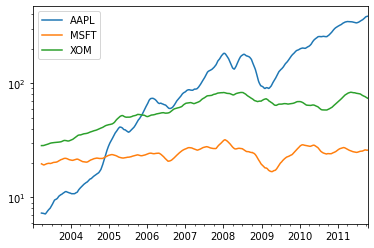

In [30]:
close_px.rolling(60).mean().plot(logy = True)

The rolling function also accepts a string indicating a fixed-size time offset rather
than a set number of periods. Using this notation can be useful for irregular time ser‐
ies. These are the same strings that you can pass to resample. For example, we could
compute a 20-day rolling mean like so

In [31]:
close_px.rolling('20D').mean()

,AAPL,MSFT,XOM
2003-01-02,7.400000,21.110000,29.220000
2003-01-03,7.425000,21.125000,29.230000
2003-01-06,7.433333,21.256667,29.473333
2003-01-07,7.432500,21.425000,29.342500
2003-01-08,7.402000,21.402000,29.240000
...,...,...,...
2011-10-10,389.351429,25.602143,72.527857
2011-10-11,388.505000,25.674286,72.835000
2011-10-12,388.531429,25.810000,73.400714
2011-10-13,388.826429,25.961429,73.905000


#### 1.3.1 Exponentially Weighted Functions

Since an exponentially weighted statistic places more weight on more recent observa‐
tions, it “adapts” faster to changes compared with the equal-weighted version.
pandas has the ewm operator to go along with rolling and expanding. Here’s an
example comparing a 60-day moving average of Apple’s stock price with an EW mov‐
ing average with span=60

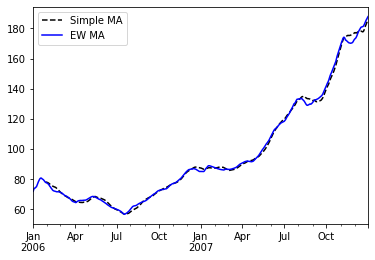

In [33]:
aapl_px = close_px.AAPL['2006':'2007']

ma60 = aapl_px.rolling(30,min_periods = 20).mean()

ewma60 = aapl_px.ewm(span = 30).mean()

ma60.plot(style = 'k--',label ='Simple MA')

ewma60.plot(style = 'b-',label = 'EW MA')

plt.legend()

#### 1.3.2 Binary Moving Window Functions

Some statistical operators, like correlation and covariance, need to operate on two
time series. As an example, financial analysts are often interested in a stock’s correla‐
tion to a benchmark index like the S&P 500. To have a look at this, we first compute
the percent change for all of our time series of interest

In [34]:
spx_px = close_px_all['SPX']

spx_rets = spx_px.pct_change()

returns = close_px.pct_change()

<AxesSubplot:>

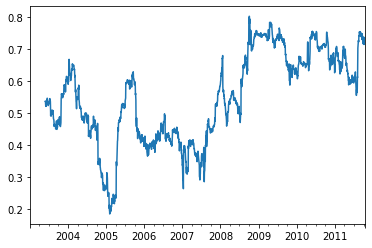

In [35]:
corr = returns.AAPL.rolling(125,min_periods=100).corr(spx_rets)

corr.plot()

Suppose you wanted to compute the correlation of the S&P 500 index with many
stocks at once. Writing a loop and creating a new DataFrame would be easy but might
get repetitive, so if you pass a Series and a DataFrame, a function like rolling_corr
will compute the correlation of the Series (spx_rets, in this case) with each column
in the DataFrame

<AxesSubplot:>

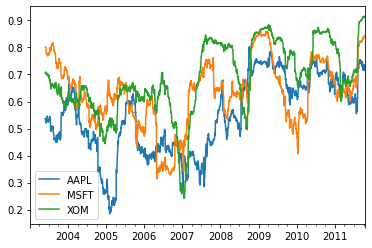

In [36]:
corr = returns.rolling(125,min_periods=100).corr(spx_rets)

corr.plot()

#### 1.3.3 User-Defined Moving Window Functions

The apply method on rolling and related methods provides a means to apply an
array function of your own devising over a moving window. The only requirement is
that the function produce a single value (a reduction) from each piece of the array.
For example, while we can compute sample quantiles using rolling(...).quan
tile(q), we might be interested in the percentile rank of a particular value over the
sample. The scipy.stats.percentileofscore function does just this 

<AxesSubplot:>

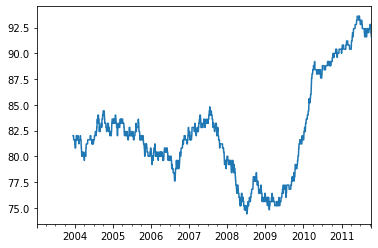

In [37]:
from scipy.stats import percentileofscore

score_at_2percent = lambda x: percentileofscore(x,0.02)

result = returns.AAPL.rolling(250).apply(score_at_2percent)

result.plot()